#### Preprocessing Pipeline

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load the EHR matrix
df = pd.read_csv("data/processed/synthea_ml_matrix.csv")

target_col = "is_high_risk" 

X = df.drop(columns=[target_col, "PATIENT_ID"], errors="ignore")
y = df[target_col]

# Automatically detect numeric (labs/vitals) vs. categorical (demographics) features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Detected {len(numeric_features)} numeric features: {numeric_features[:4]}...")
print(f"Detected {len(categorical_features)} categorical features: {categorical_features}")

Detected 3 numeric features: ['age', 'Diastolic Blood Pressure', 'Systolic Blood Pressure']...
Detected 2 categorical features: ['GENDER', 'RACE']


/tmp/ipykernel_68640/281149398.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients | Test set: {X_test.shape[0]} patients")
print(f"High-risk patient prevalence: {y_train.mean() * 100:.1f}%")

Training set: 90 patients | Test set: 23 patients
High-risk patient prevalence: 46.7%


In [3]:
#The median preserves the true patient baseline.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# handle_unknown
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"  
)

In [4]:
# Fit on training data ONLY, then transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape: {X_test_processed.shape}")
print(f"Remaining missing values in train: {np.isnan(X_train_processed).sum()}")

Processed X_train shape: (90, 8)
Processed X_test shape: (23, 8)
Remaining missing values in train: 0


#### Imbalanced-Learn

In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE 


In [6]:
# Random Forest Classifier with class_weight="balanced" to handle class imbalance
rf_balanced_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200,
                                          max_depth=10, 
                                          random_state=42, 
                                          class_weight="balanced"))
])

# Random Forest Classifier with SMOTE oversampling to handle class imbalance
rf_smote_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(n_estimators=200,
                                          max_depth=10,
                                          random_state=42)) 
])

# HistGradientBoostingClassifier with class_weight="balanced" to handle class imbalance
hgb_balanced_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(max_iter=200,
                                                max_depth=6,
                                                random_state=42,
                                                class_weight="balanced"))
])

# HistGradientBoostingClassifier with SMOTE oversampling to handle class imbalance
hgb_smote_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", HistGradientBoostingClassifier(max_iter=200,
                                                max_depth=6,
                                                random_state=42))
])  

models = {
    "Random Forest (Balanced)": rf_balanced_pipe,
    "Random Forest (SMOTE)": rf_smote_pipe,
    "HistGradientBoosting (Balanced)": hgb_balanced_pipe,
    "HistGradientBoosting (SMOTE)": hgb_smote_pipe
}



In [7]:
results = []

print("Training and evaluating models...")

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        "Model": model_name,
        "ROC AUC": round(roc_auc, 4)
    })

    print(f"{model_name}: ROC AUC = {round(roc_auc, 4)}")

# summarize results
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
print("\nModel Performance Summary:")
print(results_df.to_string(index=False))


Training and evaluating models...
Random Forest (Balanced): ROC AUC = 0.8182
Random Forest (SMOTE): ROC AUC = 0.7879
HistGradientBoosting (Balanced): ROC AUC = 0.8333
HistGradientBoosting (SMOTE): ROC AUC = 0.7955

Model Performance Summary:
                          Model  ROC AUC
HistGradientBoosting (Balanced)   0.8333
       Random Forest (Balanced)   0.8182
   HistGradientBoosting (SMOTE)   0.7955
          Random Forest (SMOTE)   0.7879


#### Threshold Tuning for 85% Recall

In [8]:
# Evaluate Default vs. PR-AUC Performance
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix

champion_model = models["HistGradientBoosting (Balanced)"]  

y_test_proba = champion_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)

print(f"--- Champion Model Baseline Metrics (Default Threshold = 0.50) ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}\n")

# Default classification report
y_pred_default = champion_model.predict(X_test)
print("Default Classification Report:")
print(classification_report(y_test, y_pred_default, target_names=["Low Risk (0)", "High Risk (1)"]))


--- Champion Model Baseline Metrics (Default Threshold = 0.50) ---
ROC-AUC Score: 0.8333
PR-AUC Score:  0.8563

Default Classification Report:
               precision    recall  f1-score   support

 Low Risk (0)       0.73      0.67      0.70        12
High Risk (1)       0.67      0.73      0.70        11

     accuracy                           0.70        23
    macro avg       0.70      0.70      0.70        23
 weighted avg       0.70      0.70      0.70        23



In [9]:
# The Clinical Threshold Tuner

def tune_clinical_threshold(y_true, y_proba, target_recall=0.85):
    """
    Scans probability thresholds to find the highest threshold that still
    guarantees the target recall (sensitivity) for high-risk patients.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Locate all indices where Recall is greater than or equal to our 85% target
    valid_indices = np.where(recalls >= target_recall)[0]
    
    # We want the highest possible threshold within that valid set to maximize Precision
    best_idx = valid_indices[-1]
    optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.50
    
    return optimal_threshold, recalls[best_idx], precisions[best_idx]

# Run the tuner on our test probabilities
opt_thresh, new_recall, new_precision = tune_clinical_threshold(y_test, y_test_proba, target_recall=0.85)

print(f"--- Clinical Threshold Tuning Results ---")
print(f"Default Decision Threshold:  0.5000")
print(f"Optimal Clinical Threshold:  {opt_thresh:.4f}")
print(f" -> Achieved High-Risk Recall:    {new_recall * 100:.1f}% (Target: >= 85.0%)")
print(f" -> Corresponding Precision:      {new_precision * 100:.1f}%")

# Generate new binary predictions using our tuned clinical threshold
y_pred_tuned = (y_test_proba >= opt_thresh).astype(int)

print("\n--- Tuned Classification Report (Custom Clinical Threshold) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Low Risk (0)", "High Risk (1)"]))

# Display the Clinical Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
print("Clinical Confusion Matrix:")
print(f"True Negatives (Correctly sent home):      {cm[0][0]}")
print(f"False Positives (Extra tests ordered):     {cm[0][1]}")
print(f"False Negatives (MISSED high-risk cases):  {cm[1][0]}  <-- Minimized!")
print(f"True Positives (Correctly caught risk):    {cm[1][1]}")

--- Clinical Threshold Tuning Results ---
Default Decision Threshold:  0.5000
Optimal Clinical Threshold:  0.3160
 -> Achieved High-Risk Recall:    90.9% (Target: >= 85.0%)
 -> Corresponding Precision:      66.7%

--- Tuned Classification Report (Custom Clinical Threshold) ---
               precision    recall  f1-score   support

 Low Risk (0)       0.88      0.58      0.70        12
High Risk (1)       0.67      0.91      0.77        11

     accuracy                           0.74        23
    macro avg       0.77      0.75      0.73        23
 weighted avg       0.78      0.74      0.73        23

Clinical Confusion Matrix:
True Negatives (Correctly sent home):      7
False Positives (Extra tests ordered):     5
False Negatives (MISSED high-risk cases):  1  <-- Minimized!
True Positives (Correctly caught risk):    10


#### Clinical Explainability with SHAP

In [14]:
import shap 
import matplotlib.pyplot as plt

preprocessor_step = champion_model.named_steps['preprocessor']
classifier_step = champion_model.named_steps['classifier']

raw_feature_names = preprocessor_step.get_feature_names_out()
clean_feature_names = [name.split("__")[-1] for name in raw_feature_names]

X_train_transformed = preprocessor_step.transform(X_train)
X_test_transformed = preprocessor_step.transform(X_test)

explainer = shap.TreeExplainer(classifier_step, X_train_transformed, feature_names=clean_feature_names)

shap_values = explainer(X_test_transformed, check_additivity=False)

print("SHAP Explainer successfully initialized and calculated!")
print(f"Tracking {len(clean_feature_names)} clinical features: {clean_feature_names}")

SHAP Explainer successfully initialized and calculated!
Tracking 8 clinical features: ['age', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'GENDER_M', 'RACE_asian', 'RACE_black', 'RACE_hawaiian', 'RACE_white']


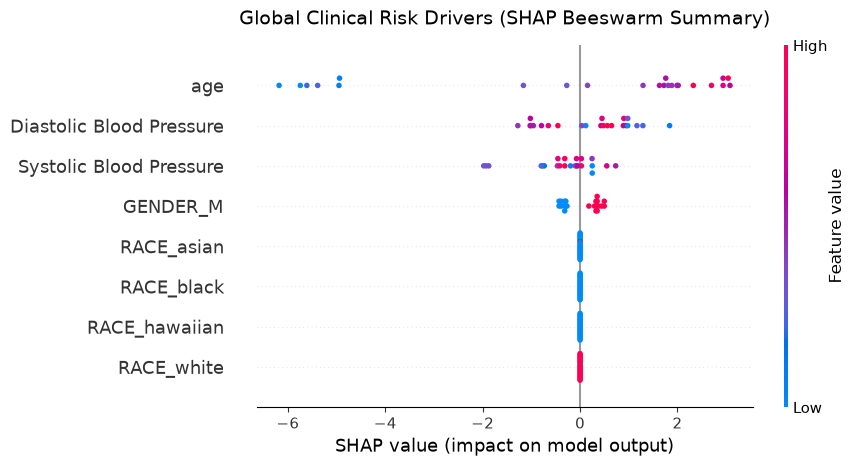

In [15]:
plt.figure(figsize=(10, 6))
plt.title("Global Clinical Risk Drivers (SHAP Beeswarm Summary)", fontsize=14, pad=15)

# Generate the beeswarm plot
# - Dots further RIGHT push a patient toward High Risk (1)
# - Dots further LEFT push a patient toward Low Risk (0)
# - RED dots = High feature value (e.g., high age, high BP)
# - BLUE dots = Low feature value
shap.plots.beeswarm(shap_values, max_display=10, show=True)

--- Triage Report: High-Risk Patient Index #2 ---
Model Predicted Probability: 61.3% (Threshold >= 31.6%)
True Clinical Status:        HIGH RISK


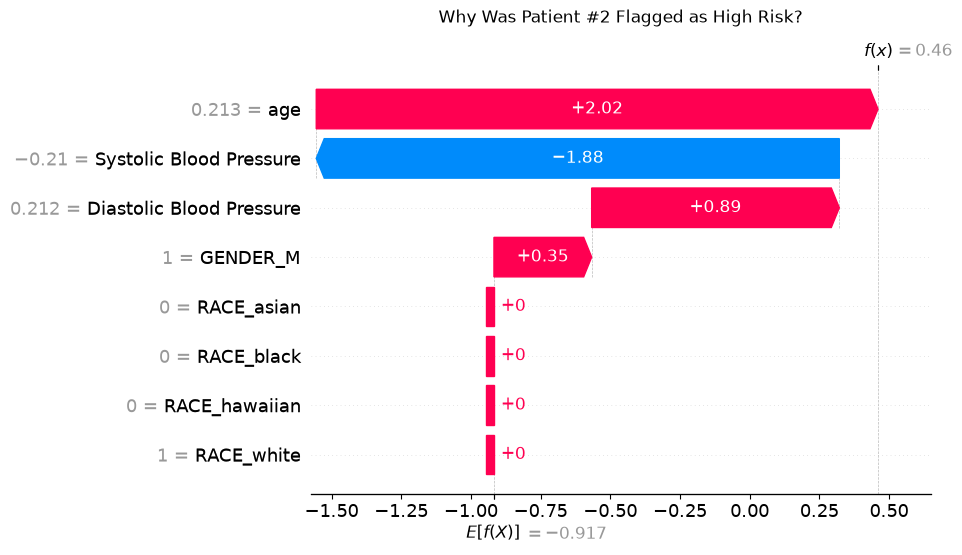

In [16]:
# Find the indices of all patients that our tuned model correctly flagged as High Risk
high_risk_indices = np.where((y_pred_tuned == 1) & (y_test == 1))[0]

# Pick the first correctly diagnosed high-risk patient (e.g., Patient X)
patient_idx = high_risk_indices[0]

print(f"--- Triage Report: High-Risk Patient Index #{patient_idx} ---")
print(f"Model Predicted Probability: {y_test_proba[patient_idx] * 100:.1f}% (Threshold >= {opt_thresh*100:.1f}%)")
print(f"True Clinical Status:        HIGH RISK")

# Generate the Waterfall Plot for this single patient
plt.figure(figsize=(8, 5))
plt.title(f"Why Was Patient #{patient_idx} Flagged as High Risk?", fontsize=12, pad=15)

# The Waterfall shows how we start at the baseline risk and add/subtract feature impacts
shap.plots.waterfall(shap_values[patient_idx], max_display=8, show=True)

#### Artifact Serialization

In [17]:
import os
import joblib
import sklearn
from datetime import datetime

os.makedirs("./models", exist_ok=True)

# Assemble the comprehensive production bundle
production_bundle = {
    "pipeline": champion_model,           
    "clinical_threshold": float(opt_thresh), 
    "feature_names": clean_feature_names, 
    "metadata": {
        "engine_version": "1.0.0",
        "algorithm": "HistGradientBoosting (Class Weights)",
        "target_variable": "is_high_risk",
        "high_risk_recall": float(new_recall),
        "high_risk_precision": float(new_precision),
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "sklearn_version": sklearn.__version__
    }
}

# Serialize to disk using joblib
artifact_path = "./models/engine1_risk_pipeline.joblib"
joblib.dump(production_bundle, artifact_path)

print(f"Production artifact successfully exported to: {artifact_path}")
print(f"Bundle keys available for FastAPI: {list(production_bundle.keys())}")

Production artifact successfully exported to: ./models/engine1_risk_pipeline.joblib
Bundle keys available for FastAPI: ['pipeline', 'clinical_threshold', 'feature_names', 'metadata']


In [18]:
# --- SIMULATING THE FASTAPI BACKEND ---
print("1. Loading production bundle from disk...")
loaded_bundle = joblib.load("./models/engine1_risk_pipeline.joblib")

loaded_pipeline = loaded_bundle["pipeline"]
loaded_thresh = loaded_bundle["clinical_threshold"]

print(f" -> Loaded Model: {loaded_bundle['metadata']['algorithm']} (v{loaded_bundle['metadata']['engine_version']})")
print(f" -> Enforcing Clinical Alarm Threshold: >= {loaded_thresh * 100:.2f}%\n")

# 2. Simulate a doctor submitting raw vitals for a new patient in the Streamlit UI
new_patient_payload = pd.DataFrame([{
    "age": 68,
    "GENDER": "M",
    "RACE": "white",
    "Body Mass Index": 33.4,
    "Systolic Blood Pressure": 158.0,
    "Diastolic Blood Pressure": 94.0,
    "Glucose": 175.0,
    "Total Cholesterol": 230.0
}])

# 3. Execute inference using our loaded components
raw_prob = loaded_pipeline.predict_proba(new_patient_payload)[0, 1]
clinical_diagnosis = "HIGH RISK (Immediate Triage)" if raw_prob >= loaded_thresh else "LOW RISK (Routine Care)"

print("--- Real-Time Patient Inference Test ---")
print(f"Patient Raw Health Score:   {raw_prob * 100:.1f}%")
print(f"Final Clinical Diagnosis:   {clinical_diagnosis}")

1. Loading production bundle from disk...
 -> Loaded Model: HistGradientBoosting (Class Weights) (v1.0.0)
 -> Enforcing Clinical Alarm Threshold: >= 31.60%

--- Real-Time Patient Inference Test ---
Patient Raw Health Score:   93.2%
Final Clinical Diagnosis:   HIGH RISK (Immediate Triage)
